## Importation

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import GradientBoostingRegressor

## Analyse Exploratoire de la Donnée

#### Chargement et aperçu du dataset

In [2]:
# Chemin d'accès vers la base de données
path = Path("train.csv")

# Vérification du chemin d'accès
if not path.exists():
     raise FileNotFoundError(f"File not found: {path}")

# Chargement des données
data = pd.read_csv(path)

# Affichage des 5 premières valeurs
data.head()

,Date,store,product,number_sold
0,2010-01-01,0,0,801
1,2010-01-02,0,0,810
2,2010-01-03,0,0,818
3,2010-01-04,0,0,796
4,2010-01-05,0,0,808


#### Valeurs manquantes

In [3]:
# Vérification des valeurs manquantes
data.isna().sum()

Date           0
store          0
product        0
number_sold    0
dtype: int64

#### Description statistique

In [4]:
# Statistiques descriptives
data.groupby('product')['number_sold'].describe()

,count,mean,std,min,25%,50%,75%,max
product,,,,,,,,
0,23009.0,726.364379,192.380245,244.0,686.0,793.0,842.0,974.0
1,23009.0,803.954279,195.151783,318.0,733.0,878.0,946.0,1066.0
2,23009.0,777.170933,208.626311,278.0,719.0,826.0,918.0,1093.0
3,23009.0,739.058325,191.214791,274.0,695.0,800.0,862.0,1065.0
4,23009.0,819.852406,198.277480,316.0,741.0,895.0,946.0,1097.0
5,23009.0,802.362728,201.554683,318.0,775.0,855.0,910.0,1107.0
6,23009.0,803.462645,208.445670,301.0,722.0,869.0,947.0,1160.0
7,23009.0,832.073232,213.099447,330.0,728.0,884.0,963.0,1205.0
8,23009.0,720.787866,205.991053,238.0,650.0,764.0,829.0,1044.0


Les moyennes de ventes des 10 produits restent relativement proches, entre 721 unités pour le produit 8 et 832 unités pour le produit 7. Aucun produit ne domine réellement les autres, ce qui montre un portefeuille assez homogène.

En revanche, les écarts-types sont élevés pour tous les produits (entre 190 et 215 unités). Les ventes fluctuent donc fortement au fil du temps, probablement sous l’effet de la saisonnalité, des promotions ou de variations de demande. Cette variabilité concerne l’ensemble des produits et non quelques cas isolés.

On remarque également que les médianes sont légèrement inférieures aux moyennes, ce qui traduit une légère asymétrie positive : certaines périodes de fortes ventes tirent les moyennes vers le haut.

In [5]:
# Statistiques descriptives
data.groupby('store')['number_sold'].describe()

,count,mean,std,min,25%,50%,75%,max
store,,,,,,,,
0,32870.0,847.521387,97.930219,546.0,798.0,866.0,912.0,1066.0
1,32870.0,719.662063,52.944443,551.0,685.0,718.0,757.0,897.0
2,32870.0,816.817706,74.094563,663.0,755.0,813.0,874.0,1053.0
3,32870.0,344.289960,38.900967,238.0,315.0,346.0,373.0,451.0
4,32870.0,974.185580,68.020418,789.0,922.0,977.0,1014.0,1205.0
5,32870.0,890.331153,79.824163,709.0,828.0,885.0,939.0,1160.0
6,32870.0,873.674901,56.072458,710.0,828.0,873.0,917.0,1013.0


Les différences entre magasins sont beaucoup plus marquées que celles observées entre produits.

Le magasin 3 se distingue nettement avec une moyenne d’environ 344 unités, contre 720 à 974 pour les autres magasins. Son faible écart-type montre toutefois que ses ventes restent stables dans le temps. Il semble donc suivre une dynamique particulière, probablement liée à sa taille, sa localisation ou son type de clientèle.

À l’inverse, les magasins 4 et 6 combinent :

- des volumes de ventes élevés,
- et une bonne stabilité.

Le magasin 4 atteint notamment près de 974 unités en moyenne avec une dispersion relativement faible, ce qui traduit des performances élevées et régulières plutôt que quelques pics exceptionnels.

#### Insights et observations

In [6]:
# convertir la date en datetime
data["Date"] = pd.to_datetime(data["Date"])

# Mettre la colonne 'date' comme index du dataframe
data.set_index('Date', inplace=True)

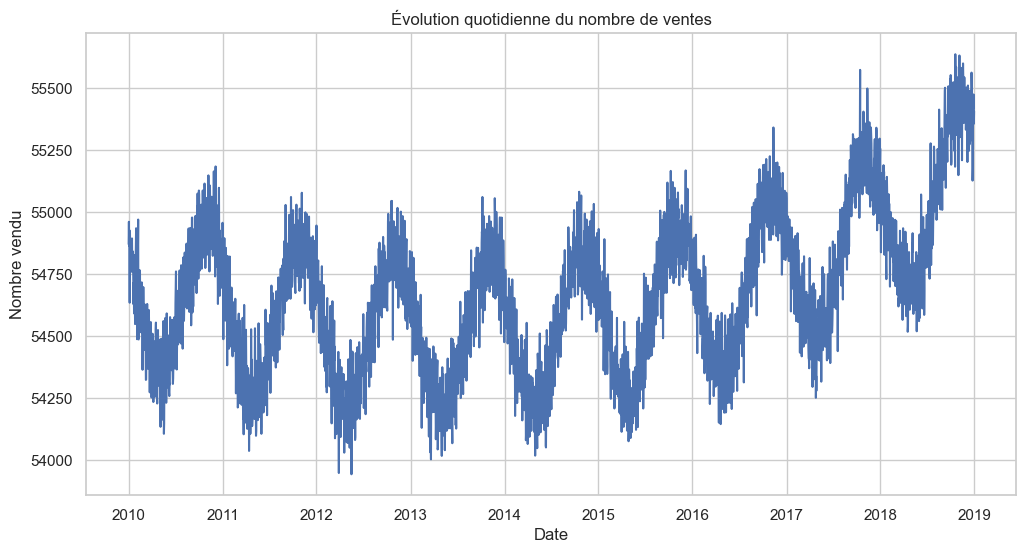

In [7]:
# Configuration du style
sns.set(style="whitegrid")

# Agrégation des ventes par jour
daily_sales = data["number_sold"].resample("D").sum()

# Figure
plt.figure(figsize=(12,6))

# Tracé de la série temporelle
plt.plot(daily_sales.index, daily_sales.values)

# Titres
plt.title("Évolution quotidienne du nombre de ventes")
plt.xlabel("Date")
plt.ylabel("Nombre vendu")

plt.show()

#### Décomposition de la série temporelle

In [8]:
# Création d'un dataframe temporaire
corr_data = pd.DataFrame({
    "number_sold": daily_sales
})

# Extraire les semaines
corr_data["week"] = corr_data.index.isocalendar().week

# Calcul moyenne et écart-type par semaine
stats = corr_data.groupby("week")["number_sold"].agg(
    Moyenne="mean",
    Ecart_type="std"
).reset_index()

# Corrélation
correlation = stats["Moyenne"].corr(stats["Ecart_type"])

print("Corrélation moyenne / écart-type :", correlation)

Corrélation moyenne / écart-type : 0.5658637085699859


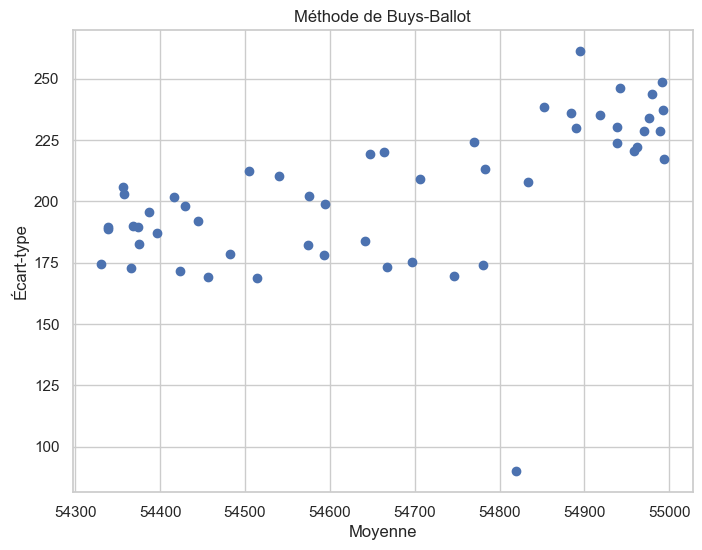

In [9]:
# Extraire le numéro de semaine
data["week"] = data.index.isocalendar().week

# Agréger les ventes par jour
daily_sales = data["number_sold"].resample("D").sum()

# Recréer un dataframe temporaire
bb_data = pd.DataFrame({
    "number_sold": daily_sales
})

# Ajouter les semaines
bb_data["week"] = bb_data.index.isocalendar().week

# Calcul moyenne / écart-type par semaine
buys_ballot = bb_data.groupby("week")["number_sold"].agg(
    Moyenne="mean",
    Ecart_type="std"
).reset_index()

# Figure
plt.figure(figsize=(8,6))

# Scatter plot Buys-Ballot
plt.scatter(
    buys_ballot["Moyenne"],
    buys_ballot["Ecart_type"]
)

# Labels
plt.xlabel("Moyenne")
plt.ylabel("Écart-type")
plt.title("Méthode de Buys-Ballot")

plt.show()

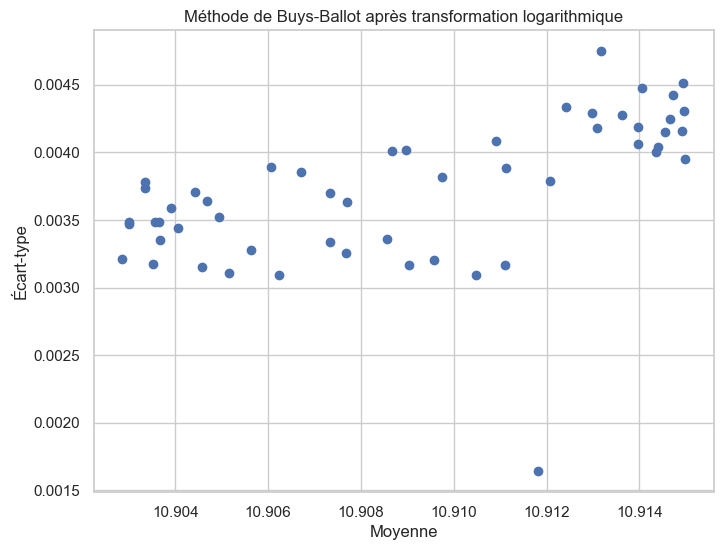

In [10]:
# Transformation logarithmique
daily_sales_log = np.log1p(daily_sales)

# Recréer un dataframe temporaire
bb_data_log = pd.DataFrame({
    "number_sold_log": daily_sales_log
})

# Ajouter les semaines
bb_data_log["week"] = bb_data_log.index.isocalendar().week

# Calcul moyenne / écart-type par semaine
buys_ballot_log = bb_data_log.groupby("week")["number_sold_log"].agg(
    Moyenne="mean",
    Ecart_type="std"
).reset_index()

# Figure
plt.figure(figsize=(8,6))

# Scatter plot Buys-Ballot après log
plt.scatter(
    buys_ballot_log["Moyenne"],
    buys_ballot_log["Ecart_type"]
)

# Labels
plt.xlabel("Moyenne")
plt.ylabel("Écart-type")
plt.title("Méthode de Buys-Ballot après transformation logarithmique")

plt.show()

La méthode de Buys–Ballot table montre une légère augmentation de l’écart-type lorsque la moyenne augmente. Cependant, cette relation reste modérée.

La corrélation entre la moyenne et l’écart-type est de :

> r≈0.566

Cette valeur ne permet pas de conclure à une structure clairement multiplicative.

Une transformation logarithmique a ensuite été appliquée, mais le nuage de points obtenu reste très proche du graphique initial. La variance ne semble donc pas significativement stabilisée par le logarithme.

La série paraît ainsi davantage suivre une structure **additive** qu’une structure multiplicative.

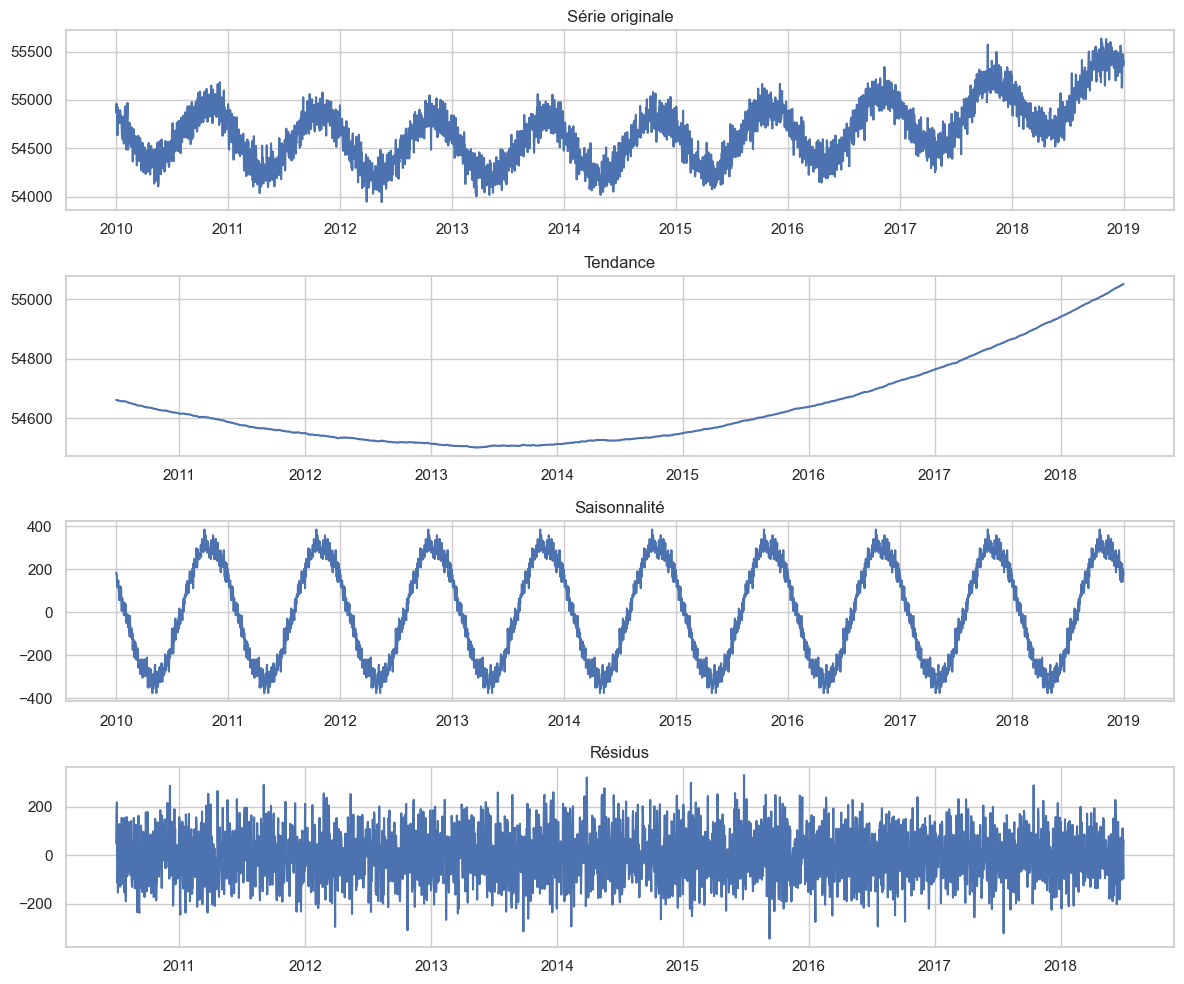

In [11]:
# Agréger les ventes par jour
daily_sales = data["number_sold"].resample("D").sum()

# Décomposition saisonnière
decomposition = seasonal_decompose(
    daily_sales,
    model="additive",
    period=365
)

# Figure
plt.figure(figsize=(12,10))

# Série originale
plt.subplot(4,1,1)
plt.plot(daily_sales)
plt.title("Série originale")

# Tendance
plt.subplot(4,1,2)
plt.plot(decomposition.trend)
plt.title("Tendance")

# Saisonnalité
plt.subplot(4,1,3)
plt.plot(decomposition.seasonal)
plt.title("Saisonnalité")

# Résidus
plt.subplot(4,1,4)
plt.plot(decomposition.resid)
plt.title("Résidus")

plt.tight_layout()
plt.show()

La décomposition de la série met clairement en évidence trois composantes principales :

- une tendance,
- une saisonnalité,
- et un bruit résiduel.

La tendance montre d’abord une légère baisse entre 2010 et 2013, suivie d’une hausse progressive jusqu’en 2019. Les ventes augmentent donc globalement sur la fin de la période.

La composante saisonnière est très marquée et présente un cycle régulier qui se répète chaque année. Cela confirme l’existence d’une forte saisonnalité annuelle dans les données.

Enfin, les résidus restent globalement centrés autour de zéro et ne montrent pas de structure particulière. La variance semble relativement stable dans le temps, ce qui renforce l’hypothèse d’une structure additive.

### Approche statistique : Méthodologie de Box-Jenkins

#### Analyse de la stationnarité

Hypothèse nulle (H0) : la série temporelle n’est pas stationnaire <br>
**Règle de décision** <br>
- p-value < 0.05 : on rejette H0 donc la série est stationnaire
- p-value ≥ 0.05 : on ne rejette pas H0 donc la série est non stationnaire

In [12]:
# Agrégation des ventes par jour
daily_sales = data["number_sold"].resample("D").sum()

# Test ADF
result = adfuller(daily_sales)

# Affichage des résultats
print("p-value :", result[1])

p-value : 0.10779573173602797


In [13]:
# Agrégation des ventes par jour
daily_sales = data["number_sold"].resample("D").sum()

# Différenciation d'ordre 1
daily_sales_diff = daily_sales.diff().dropna()

# Test ADF
result = adfuller(daily_sales_diff)

# Résultat
print("p-value :", result[1])

p-value : 3.894249829397963e-10


#### Identification du modèle

On cherche donc à determiner les paramètres du modèle choisi **SARIMA(p,d,q)(P,D,Q,7)**

In [14]:
# Différenciation saisonnière
daily_sales_seasonal = daily_sales_diff.diff(7).dropna()

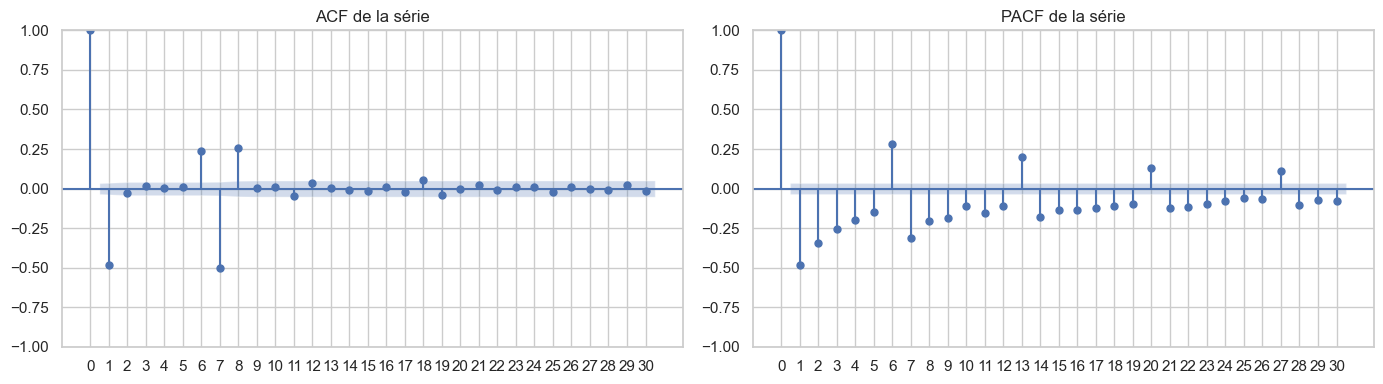

In [15]:
# Visualisation ACF et PACF
fig, ax = plt.subplots(1, 2, figsize=(14,4))

# ACF
plot_acf(daily_sales_seasonal, lags=30, ax=ax[0])

# PACF
plot_pacf(daily_sales_seasonal, lags=30, ax=ax[1])

# Afficher tous les ticks
ax[0].set_xticks(range(0,31,1))
ax[1].set_xticks(range(0,31,1))

# Titres
ax[0].set_title("ACF de la série")
ax[1].set_title("PACF de la série")

plt.tight_layout()
plt.show()

number_sold → SARIMA(p,1,q)(P,1,Q,7)
- p = 1
- q = 1
- P = 1
- Q = 1

#### Entrainement du modèle

In [16]:
# Modèle SARIMA
model = SARIMAX(
    daily_sales,
    order=(0,1,1),
    seasonal_order=(0,1,1,7)
)

# Entraînement
sarima_fit = model.fit()

# Résumé
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       number_sold   No. Observations:                 3287
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood              -19431.190
Date:                           Tue, 19 May 2026   AIC                          38868.379
Time:                                   10:34:22   BIC                          38886.665
Sample:                               01-01-2010   HQIC                         38874.927
                                    - 12-31-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8030      0.011    -75.533      0.000      -0.824      -0.782
ma.S.L7       -0.9994      0.021    -48.162

#### Prévision sur les valeurs futures

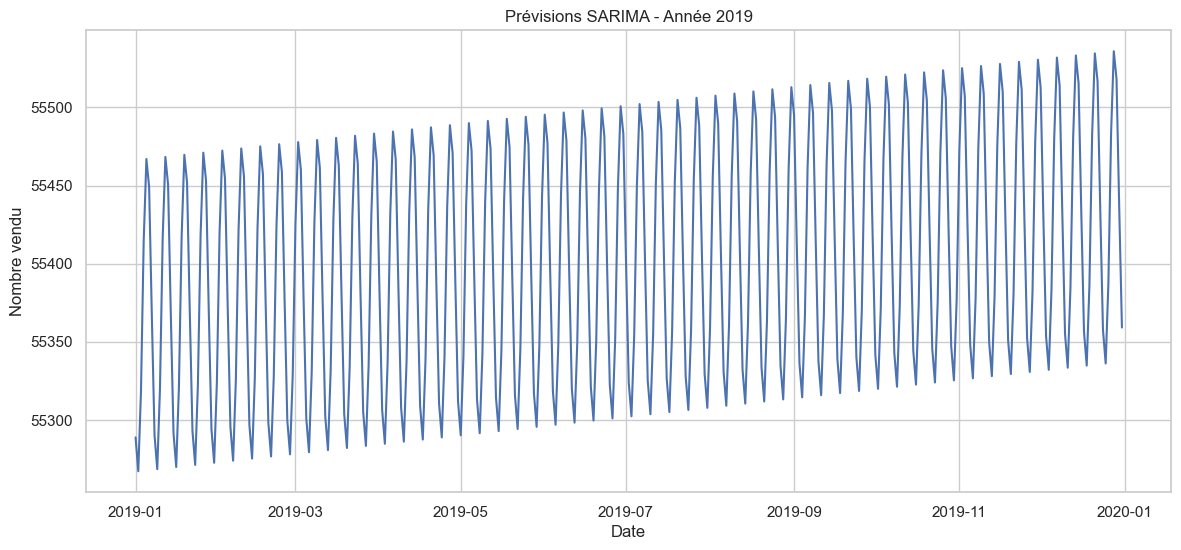

In [17]:
# Prédiction sur 2019
forecast_2019 = sarima_fit.forecast(steps=365)

# Affichage
plt.figure(figsize=(14,6))

plt.plot(forecast_2019)

plt.title("Prévisions SARIMA - Année 2019")
plt.xlabel("Date")
plt.ylabel("Nombre vendu")

plt.show()

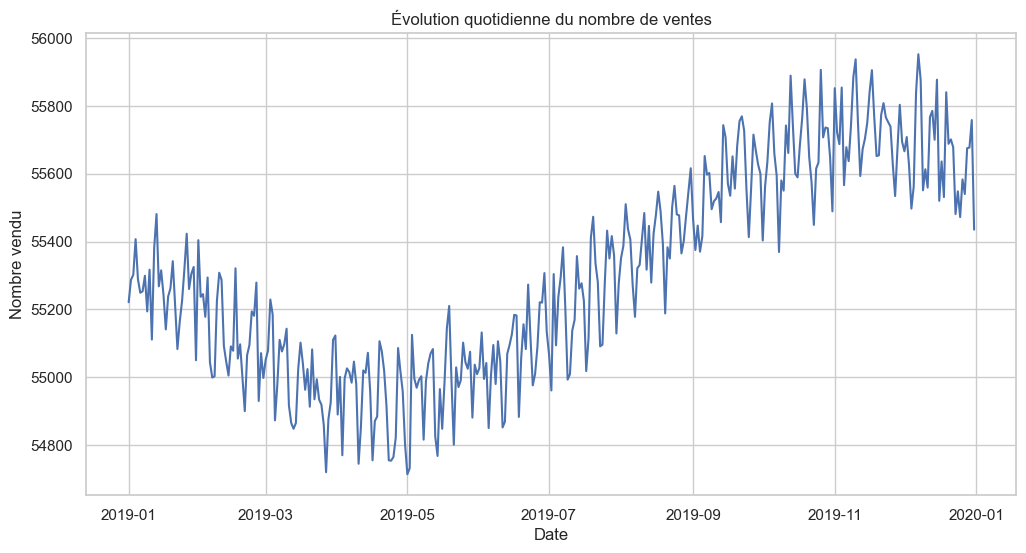

In [18]:
# Chemin d'accès vers la base de données
path_test = Path("test.csv")

# Vérification du chemin d'accès
if not path_test.exists():
     raise FileNotFoundError(f"File not found: {path_test}")

# Chargement des données
data_test = pd.read_csv(path_test)


# convertir la date en datetime
data_test["Date"] = pd.to_datetime(data_test["Date"])

# Mettre la colonne 'date' comme index du dataframe
data_test.set_index('Date', inplace=True)

# Configuration du style
sns.set(style="whitegrid")

# Agrégation des ventes par jour
daily_sales_test = data_test["number_sold"].resample("D").sum()

# Figure
plt.figure(figsize=(12,6))

# Tracé de la série temporelle
plt.plot(daily_sales_test.index, daily_sales_test.values)

# Titres
plt.title("Évolution quotidienne du nombre de ventes")
plt.xlabel("Date")
plt.ylabel("Nombre vendu")

plt.show()

In [19]:
# Valeurs réelles
y_true = daily_sales_test.values

# Prédictions SARIMA
y_pred = forecast_2019.values

# Calcul du MAPE
mape = mean_absolute_percentage_error(y_true, y_pred)

# Calcul du MAE
mae = mean_absolute_error(y_true, y_pred)

# Affichage
print("MAE :", mae)
print("MAPE :", mape)
print("MAPE (%) :", mape * 100)

MAE : 258.71607536387893
MAPE : 0.004684956469460455
MAPE (%) : 0.46849564694604556


Le modèle :

> SARIMA(0,1,1)(0,1,1,7)

capture correctement les deux principales composantes de la série :

- la tendance haussière progressive,
- ainsi que la saisonnalité hebdomadaire.

Les prévisions reproduisent des oscillations régulières dont le niveau augmente progressivement tout au long de l’année 2019, en cohérence avec la dynamique générale observée dans les données réelles.

Cependant, le modèle lisse fortement la variabilité de la série. Les fluctuations restent très régulières et le modèle ne parvient pas à reproduire les variations plus brutales observées dans les données réelles, notamment durant le premier semestre où la série est plus instable et erratique. Le second semestre est en revanche mieux représenté, car la série réelle suit une évolution plus régulière et proche de celle prédite par le modèle.

Les performances restent néanmoins excellentes :

- MAE ≈ 258.7
- MAPE ≈ 0.47 %

Le MAPE très faible montre que les prévisions restent globalement très proches des valeurs réelles malgré certaines difficultés à capturer les variations locales les plus irrégulières.

### Approche Machine Learning

In [20]:
# Chargement train
path_train = Path("train.csv")
data = pd.read_csv(path_train)

# Conversion date
data["Date"] = pd.to_datetime(data["Date"])

# Chargement test
path_test = Path("test.csv")
data_test = pd.read_csv(path_test)

# Conversion date
data_test["Date"] = pd.to_datetime(data_test["Date"])

#### Feature Engineering

In [21]:
# Features temporelles

## Train
data["dayofweek"] = data["Date"].dt.dayofweek
data["month"] = data["Date"].dt.month
data["year"] = data["Date"].dt.year
data["day"] = data["Date"].dt.day
data["weekofyear"] = data["Date"].dt.isocalendar().week.astype(int)

# Week-end
data["is_weekend"] = data["dayofweek"].isin([5,6]).astype(int)

## Test
data_test["dayofweek"] = data_test["Date"].dt.dayofweek
data_test["month"] = data_test["Date"].dt.month
data_test["year"] = data_test["Date"].dt.year
data_test["day"] = data_test["Date"].dt.day
data_test["weekofyear"] = data_test["Date"].dt.isocalendar().week.astype(int)

# Week-end
data_test["is_weekend"] = data_test["dayofweek"].isin([5,6]).astype(int)


# Création des Lags (Train)
data["lag_1"] = data.groupby(
    ["store", "product"]
)["number_sold"].shift(1)

data["lag_7"] = data.groupby(
    ["store", "product"]
)["number_sold"].shift(7)

data["lag_30"] = data.groupby(
    ["store", "product"]
)["number_sold"].shift(30)

# Rolling Features (Train)
data["rolling_mean_7"] = data.groupby(
    ["store", "product"]
)["number_sold"].transform(
    lambda x: x.rolling(7).mean()
)

data["rolling_mean_30"] = data.groupby(
    ["store", "product"]
)["number_sold"].transform(
    lambda x: x.rolling(30).mean()
)


# Écart-types mobiles (Train)
data["rolling_std_7"] = data.groupby(
    ["store", "product"]
)["number_sold"].transform(
    lambda x: x.rolling(7).std()
)

# Nettoyage
data = data.dropna()

In [22]:
# Variables explicatives
features = [
    "store",
    "product",
    "dayofweek",
    "month",
    "year",
    "day",
    "weekofyear",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7"
]

X_train = data[features]
y_train = data["number_sold"]

In [23]:
# Preparation des données de test

# Concatenation des données de train et de test
full_data = pd.concat([data, data_test], sort=False)

# Recalcul des lags
full_data["lag_1"] = full_data.groupby(
    ["store", "product"]
)["number_sold"].shift(1)

full_data["lag_7"] = full_data.groupby(
    ["store", "product"]
)["number_sold"].shift(7)

full_data["lag_30"] = full_data.groupby(
    ["store", "product"]
)["number_sold"].shift(30)

# Recalcul rolling feature
full_data["rolling_mean_7"] = full_data.groupby(
    ["store", "product"]
)["number_sold"].transform(
    lambda x: x.rolling(7).mean()
)

full_data["rolling_mean_30"] = full_data.groupby(
    ["store", "product"]
)["number_sold"].transform(
    lambda x: x.rolling(30).mean()
)

full_data["rolling_std_7"] = full_data.groupby(
    ["store", "product"]
)["number_sold"].transform(
    lambda x: x.rolling(7).std()
)

# Extraction des données de test
test_final = full_data[full_data["Date"].dt.year == 2019]
X_test = test_final[features]

#### Entrainement du modèle

In [24]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200,
                          random_state=42)

#### Prédictions

In [25]:
y_pred = gb_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(
    test_final["number_sold"],
    y_pred
)

print("MAE :", mae)

mape = mean_absolute_percentage_error(
    test_final["number_sold"],
    y_pred
)

print("MAPE :", mape)
print("MAPE (%) :", mape * 100)

MAE : 8.539414815609474
MAPE : 0.012071173561192855
MAPE (%) : 1.2071173561192856


#### Visualisation

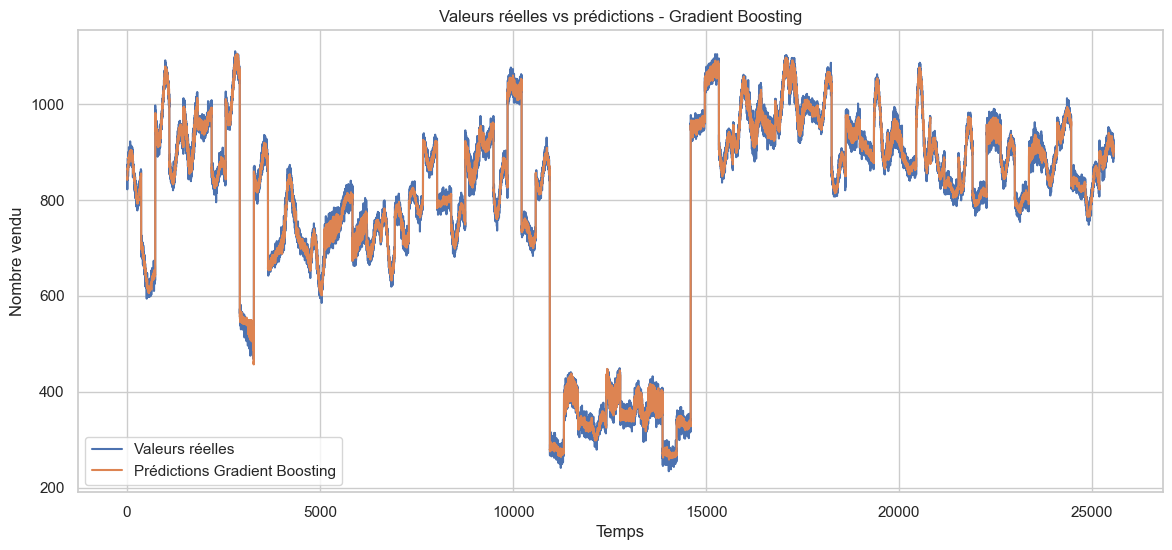

In [26]:
# Figure
plt.figure(figsize=(14,6))

# Valeurs réelles 2019
plt.plot(
    test_final["number_sold"].values,
    label="Valeurs réelles"
)

# Prédictions Gradient Boosting
plt.plot(
    y_pred,
    label="Prédictions Gradient Boosting"
)

# Titres
plt.title("Valeurs réelles vs prédictions - Gradient Boosting")
plt.xlabel("Temps")
plt.ylabel("Nombre vendu")

plt.legend()

plt.show()

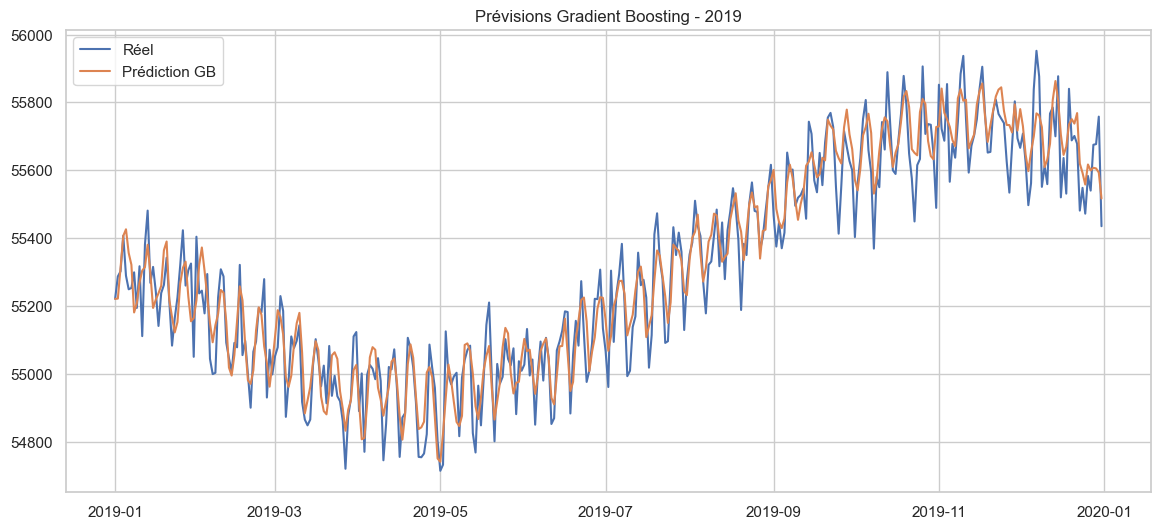

In [29]:
pred_df = test_final.copy()

pred_df["prediction"] = y_pred

# Agrégation quotidienne
daily_pred = pred_df.groupby("Date")["prediction"].sum()

daily_real = pred_df.groupby("Date")["number_sold"].sum()

plt.figure(figsize=(14,6))

plt.plot(daily_real, label="Réel")
plt.plot(daily_pred, label="Prédiction GB")

plt.legend()

plt.title("Prévisions Gradient Boosting - 2019")

plt.show()

Le modèle Gradient Boosting reproduit très fidèlement la série réelle sur l’année 2019. Contrairement au modèle SARIMA, les prédictions suivent non seulement la tendance générale et la saisonnalité, mais également une grande partie des fluctuations locales de la série.

Le modèle parvient notamment à mieux capturer :

- les variations irrégulières,
- les changements rapides de niveau,
- ainsi que les pics et creux observés au cours de l’année.

Les courbes réelle et prédite restent très proches sur presque toute la période, ce qui montre que le feature engineering (lags, rolling statistics et variables calendaires) apporte une information très utile au modèle.

Les performances obtenues sont excellentes :

- MAE ≈ 8.54
- MAPE ≈ 1.21 %

Le MAE extrêmement faible montre que les prédictions sont très proches des valeurs réelles en moyenne. Même si le MAPE est légèrement supérieur à celui du SARIMA, le modèle Gradient Boosting capture visuellement beaucoup mieux la dynamique réelle de la série, notamment les variations locales que le SARIMA avait tendance à lisser.